<a href="https://colab.research.google.com/github/karunachaudhary2112/CodeAlpha_ProjectName/blob/main/task_03_data_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File 'demo_titanic_like.csv' not found. Creating a dummy CSV file.
Dummy 'demo_titanic_like.csv' created successfully.


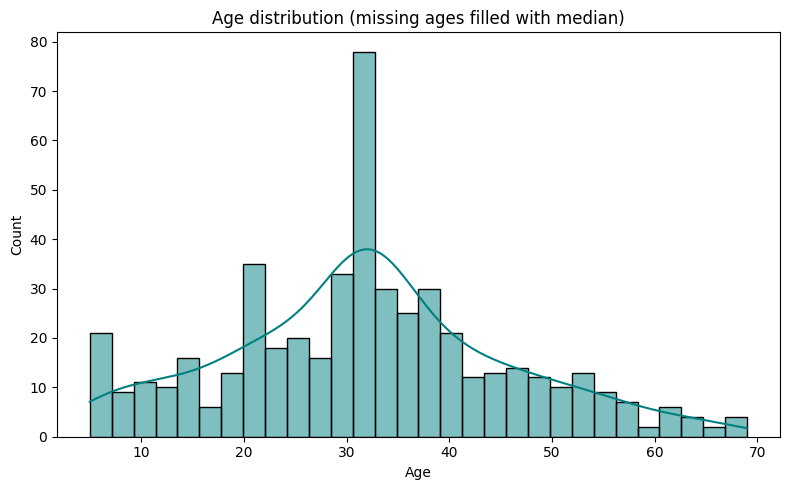

/tmp/ipykernel_2048/2260492331.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=surv_by_sex, palette='pastel')


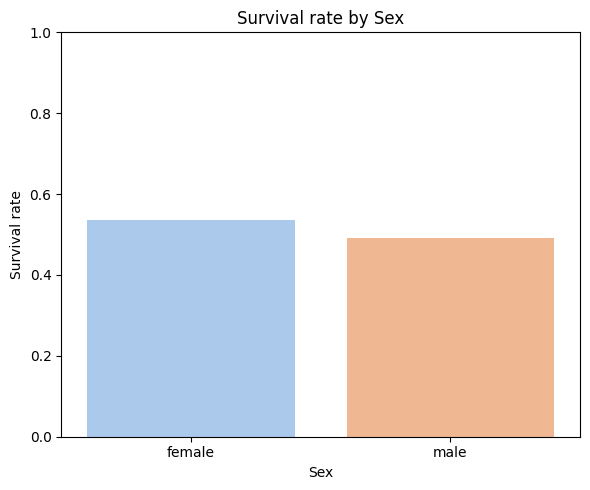

/tmp/ipykernel_2048/2260492331.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=surv_by_class, palette='muted')


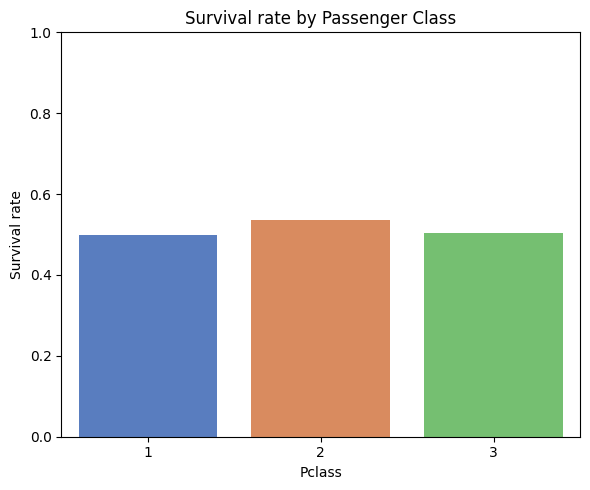

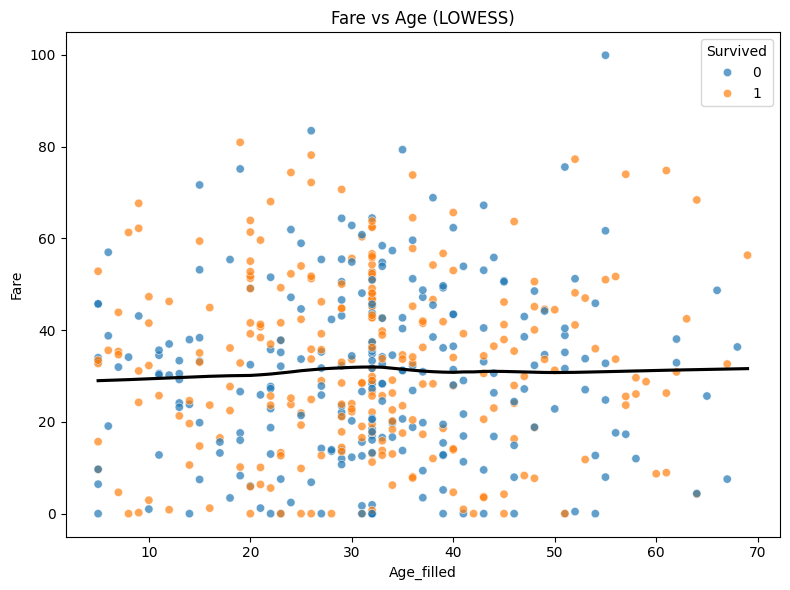

/tmp/ipykernel_2048/2260492331.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=surv_by_sex, ax=axs[0,1], palette='Set2')
/tmp/ipykernel_2048/2260492331.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=surv_by_class, ax=axs[1,0], palette='Set1')
/tmp/ipykernel_2048/2260492331.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Fare', data=df, ax=axs[1,1], palette='cool')


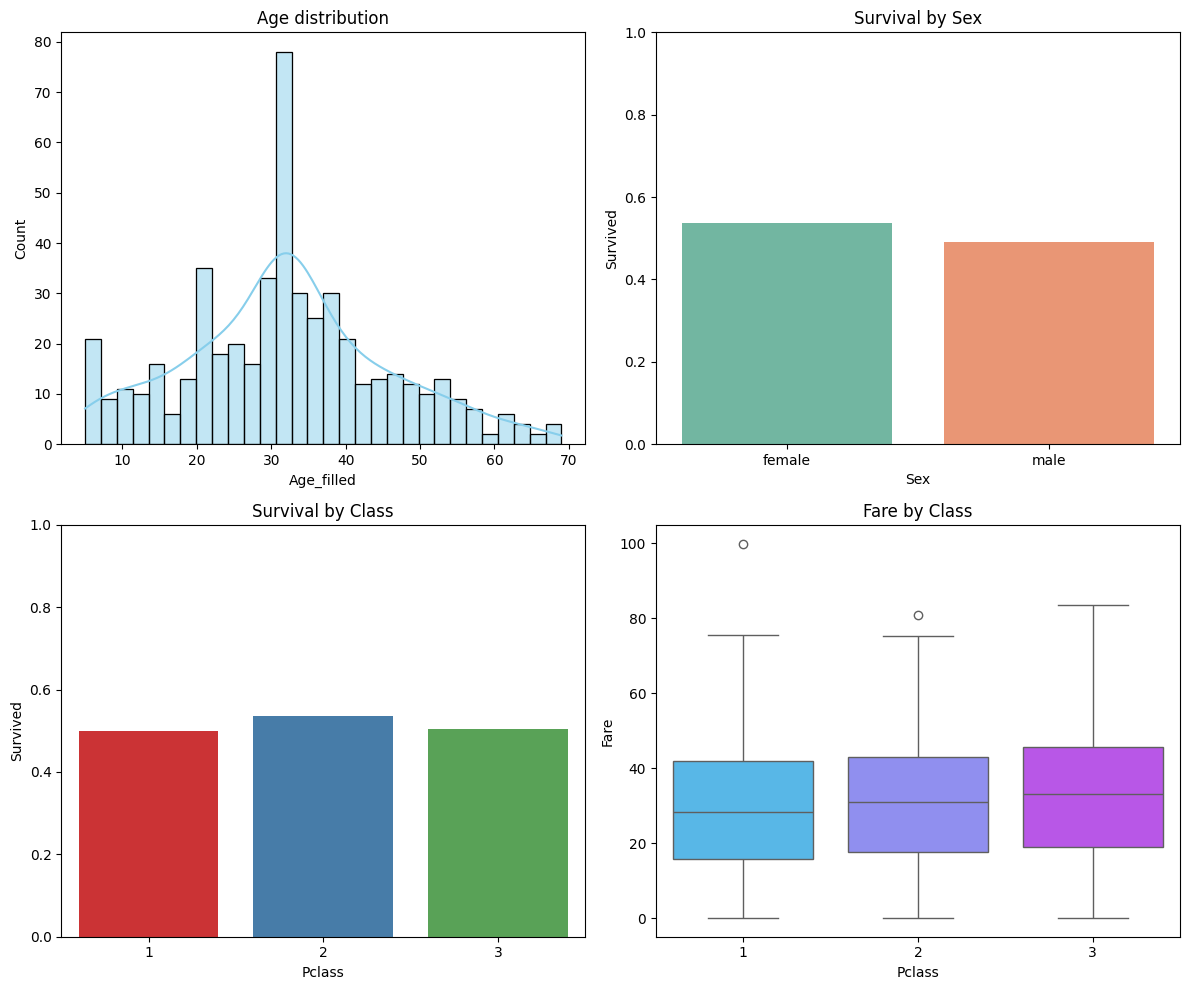

Saved plots:
plot_age_distribution.png
plot_survival_by_sex.png
plot_survival_by_pclass.png
plot_fare_vs_age.png
plot_dashboard.png


In [1]:
# This cell creates several polished visualizations from the demo CSV and saves them as PNGs.
# It will load the saved CSV, create plots (age distribution, survival by sex, survival rate by Pclass, fare vs age scatter with regression),
# and save images. It uses tqdm for progress display.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np

csv_filename = 'demo_titanic_like.csv'

# Check if the CSV file exists, if not, create a dummy one
try:
    df = pd.read_csv(csv_filename)
except FileNotFoundError:
    print(f"File '{csv_filename}' not found. Creating a dummy CSV file.")
    # Create dummy data resembling Titanic dataset
    np.random.seed(42)
    data_size = 500
    dummy_data = {
        'PassengerId': range(1, data_size + 1),
        'Survived': np.random.randint(0, 2, data_size),
        'Pclass': np.random.choice([1, 2, 3], data_size, p=[0.2, 0.3, 0.5]),
        'Name': [f'Passenger_{i}' for i in range(data_size)],
        'Sex': np.random.choice(['male', 'female'], data_size),
        'Age': np.random.normal(loc=30, scale=15, size=data_size).clip(5, 70).round(),
        'SibSp': np.random.randint(0, 4, data_size),
        'Parch': np.random.randint(0, 3, data_size),
        'Ticket': [f'T{i}' for i in range(data_size)],
        'Fare': np.random.normal(loc=30, scale=20, size=data_size).clip(0, 200).round(2),
        'Cabin': [f'C{i}' if np.random.rand() < 0.3 else np.nan for i in range(data_size)],
        'Embarked': np.random.choice(['S', 'C', 'Q', np.nan], data_size, p=[0.7, 0.1, 0.1, 0.1])
    }
    df = pd.DataFrame(dummy_data)
    df['Age'] = df['Age'].apply(lambda x: x if np.random.rand() > 0.1 else np.nan) # Add some missing ages
    df.to_csv(csv_filename, index=False)
    print(f"Dummy '{csv_filename}' created successfully.")

# Basic cleaning for plotting
df['Age_filled'] = df['Age'].fillna(df['Age'].median())

plots = []

# 1 Age distribution with KDE
plt.figure(figsize=(8,5))
sns.histplot(df['Age_filled'], bins=30, kde=True, color='teal')
plt.title('Age distribution (missing ages filled with median)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_age_distribution.png')
plt.show()
plots.append('plot_age_distribution.png')

# 2 Survival rate by Sex (bar plot)
plt.figure(figsize=(6,5))
surv_by_sex = df.groupby('Sex')['Survived'].mean().reset_index()
sns.barplot(x='Sex', y='Survived', data=surv_by_sex, palette='pastel')
plt.ylim(0,1)
plt.title('Survival rate by Sex')
plt.ylabel('Survival rate')
plt.tight_layout()
plt.savefig('plot_survival_by_sex.png')
plt.show()
plots.append('plot_survival_by_sex.png')

# 3 Survival rate by Pclass
plt.figure(figsize=(6,5))
surv_by_class = df.groupby('Pclass')['Survived'].mean().reset_index()
sns.barplot(x='Pclass', y='Survived', data=surv_by_class, palette='muted')
plt.ylim(0,1)
plt.title('Survival rate by Passenger Class')
plt.ylabel('Survival rate')
plt.tight_layout()
plt.savefig('plot_survival_by_pclass.png')
plt.show()
plots.append('plot_survival_by_pclass.png')

# 4 Fare vs Age scatter with regression and color by Survived
plt.figure(figsize=(8,6))
sns.scatterplot(x='Age_filled', y='Fare', hue='Survived', data=df, alpha=0.7)
sns.regplot(x='Age_filled', y='Fare', data=df, scatter=False, lowess=True, color='black')
plt.title('Fare vs Age (LOWESS)')
plt.tight_layout()
plt.savefig('plot_fare_vs_age.png')
plt.show()
plots.append('plot_fare_vs_age.png')

# 5 Dashboard-style combined figure
fig, axs = plt.subplots(2,2, figsize=(12,10))

sns.histplot(df['Age_filled'], bins=30, kde=True, ax=axs[0,0], color='skyblue')
axs[0,0].set_title('Age distribution')

sns.barplot(x='Sex', y='Survived', data=surv_by_sex, ax=axs[0,1], palette='Set2')
axs[0,1].set_ylim(0,1)
axs[0,1].set_title('Survival by Sex')

sns.barplot(x='Pclass', y='Survived', data=surv_by_class, ax=axs[1,0], palette='Set1')
axs[1,0].set_ylim(0,1)
axs[1,0].set_title('Survival by Class')

sns.boxplot(x='Pclass', y='Fare', data=df, ax=axs[1,1], palette='cool')
axs[1,1].set_title('Fare by Class')

plt.tight_layout()
plt.savefig('plot_dashboard.png')
plt.show()
plots.append('plot_dashboard.png')

print('Saved plots:')
for p in plots:
    print(p)
